# 🛒 Instacart Customer Shopping Behavior Analysis

## Exploratory Data Analysis & Data Wrangling

This project analyzes customer purchasing behavior on **Instacart**, an online grocery delivery platform. The objective is to clean and integrate five related datasets and use exploratory data analysis to understand **when customers shop, how frequently they return, basket size, product popularity, and repurchase behavior**.

The dataset is an adapted version of Instacart's public 2017 market-basket dataset, prepared for an academic Data Science project. This portfolio version preserves the analytical scope while reorganizing the work into a concise, reproducible case study.

### Business questions
- When are orders most frequently placed?
- How long do customers typically wait between orders?
- How does purchasing activity vary by day and hour?
- Which products are most frequently purchased and repurchased?
- How large are customer baskets?
- Which products are most often added first to the cart?

## 1. Setup and data loading
The five source tables are loaded from the repository `data/` directory using `;` as the delimiter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
BASE = Path('..')
DATA = BASE / 'data'

orders = pd.read_csv(DATA / 'instacart_orders.csv', sep=';')
products = pd.read_csv(DATA / 'products.csv', sep=';')
aisles = pd.read_csv(DATA / 'aisles.csv', sep=';')
departments = pd.read_csv(DATA / 'departments.csv', sep=';')
order_products = pd.read_csv(DATA / 'order_products.csv', sep=';')

for name, df in {'orders':orders,'products':products,'aisles':aisles,'departments':departments,'order_products':order_products}.items():
    print(f'{name:15s}: {df.shape[0]:,} rows × {df.shape[1]} columns')

orders         : 478,967 rows × 6 columns
products       : 49,694 rows × 4 columns
aisles         : 134 rows × 2 columns
departments    : 21 rows × 2 columns
order_products : 4,545,007 rows × 4 columns


### Data model
`orders` describes each order; `order_products` is the order-item fact table; `products`, `aisles`, and `departments` provide product metadata. Together they allow order-level, customer-level, and product-level analysis.

In [2]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


## 2. Data quality assessment
We inspect duplicates, missing values, ranges, and data types before analysis.

In [3]:
summary = []
for name, df in {'orders':orders,'products':products,'aisles':aisles,'departments':departments,'order_products':order_products}.items():
    summary.append({
        'table': name,
        'rows': len(df),
        'duplicate_rows': int(df.duplicated().sum()),
        'missing_cells': int(df.isna().sum().sum())
    })
pd.DataFrame(summary)

,table,rows,duplicate_rows,missing_cells
0,orders,478967,15,28819
1,products,49694,0,1258
2,aisles,134,0,0
3,departments,21,0,0
4,order_products,4545007,0,836


In [4]:
print('Missing values — orders:')
print(orders.isna().sum())
print()
print('Missing values — products:')
print(products.isna().sum())
print()
print('Missing values — order_products:')
print(order_products.isna().sum())

Missing values — orders:
order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64

Missing values — products:
product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

Missing values — order_products:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


### Cleaning decisions
- Exact duplicate rows are removed from the order table.
- Missing `days_since_prior_order` values are expected for each customer's first order and are therefore retained.
- Missing product names are labeled `Unknown` so records remain available for ID-based analysis.
- Missing `add_to_cart_order` values are retained because the item/order relationship is still valid; analyses that require cart position use only non-null positions.
- Identifier columns are kept as integer-compatible types.

These choices avoid discarding valid transactions solely because a descriptive field is unavailable.

In [5]:
orders = orders.drop_duplicates().copy()
products = products.drop_duplicates().copy()
aisles = aisles.drop_duplicates().copy()
departments = departments.drop_duplicates().copy()
order_products = order_products.drop_duplicates().copy()

products['product_name'] = products['product_name'].fillna('Unknown')

for df, cols in [(orders,['order_id','user_id','order_number','order_dow','order_hour_of_day']),
                 (products,['product_id','aisle_id','department_id']),
                 (aisles,['aisle_id']), (departments,['department_id']),
                 (order_products,['order_id','product_id','reordered'])]:
    for col in cols:
        df[col] = df[col].astype('int64')

print('Clean orders:', orders.shape)
print('Hour range:', orders.order_hour_of_day.min(), 'to', orders.order_hour_of_day.max())
print('Day-of-week range:', orders.order_dow.min(), 'to', orders.order_dow.max())

Clean orders: (478952, 6)
Hour range: 0 to 23
Day-of-week range: 0 to 6


The observed ranges are valid: hours fall between **0–23** and day-of-week values between **0–6**, consistent with the data dictionary.

## 3. Exploratory Data Analysis
### 3.1 Orders by hour of day

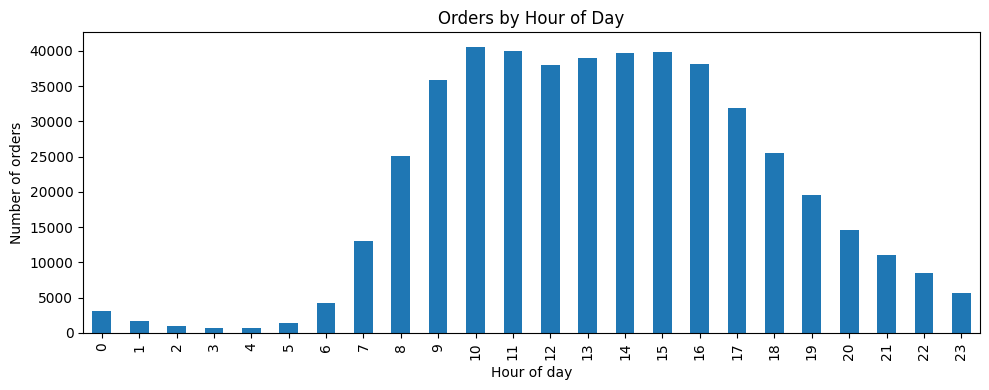

Peak hour: 10 | Orders: 40,578


In [6]:
hourly = orders['order_hour_of_day'].value_counts().sort_index()
ax = hourly.plot(kind='bar', figsize=(10,4))
ax.set_title('Orders by Hour of Day')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of orders')
plt.tight_layout(); plt.show()
print('Peak hour:', hourly.idxmax(), '| Orders:', f'{hourly.max():,}')

Ordering activity is concentrated during daytime hours, with substantially lower activity overnight. The peak identifies the strongest period of platform demand in this sample.

### 3.2 Orders by day of week

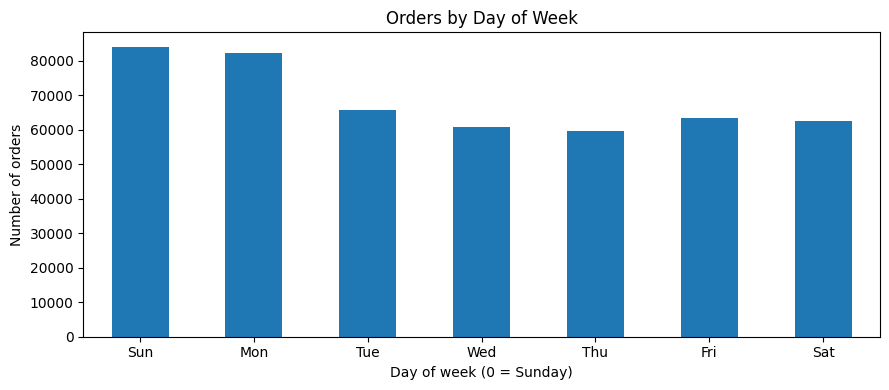

order_dow
Sun    84090
Mon    82185
Tue    65833
Wed    60897
Thu    59810
Fri    63488
Sat    62649
Name: count, dtype: int64


In [7]:
dow = orders['order_dow'].value_counts().sort_index()
labels = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
ax = dow.plot(kind='bar', figsize=(9,4))
ax.set_title('Orders by Day of Week')
ax.set_xlabel('Day of week (0 = Sunday)')
ax.set_ylabel('Number of orders')
ax.set_xticklabels(labels, rotation=0)
plt.tight_layout(); plt.show()
print(dow.rename(index=dict(enumerate(labels))))

### 3.3 Time between orders

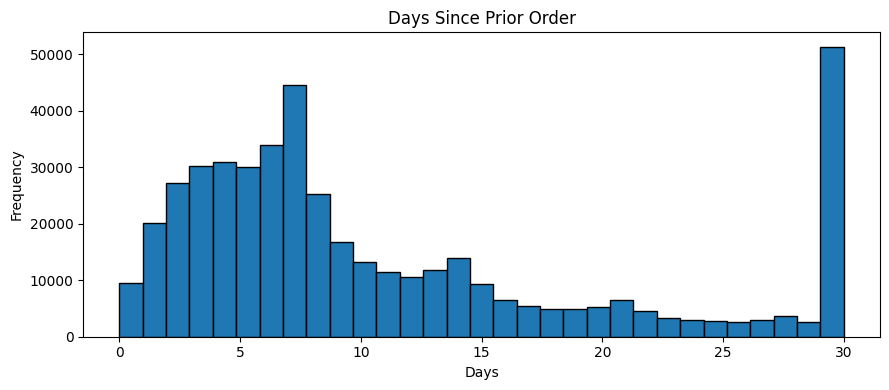

Minimum: 0 days | Median: 7 days | Maximum: 30 days


In [8]:
wait = orders['days_since_prior_order'].dropna()
ax = wait.plot(kind='hist', bins=31, figsize=(9,4), edgecolor='black')
ax.set_title('Days Since Prior Order')
ax.set_xlabel('Days')
ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()
print(f'Minimum: {wait.min():.0f} days | Median: {wait.median():.0f} days | Maximum: {wait.max():.0f} days')

The distribution reveals both short repeat cycles and a strong concentration at the dataset's 30-day upper bound. That upper-bound concentration should be interpreted cautiously because it may include customers whose interval is 30 days **or more**, depending on how the adapted dataset was constructed.

### 3.4 Wednesday vs. Saturday ordering hours

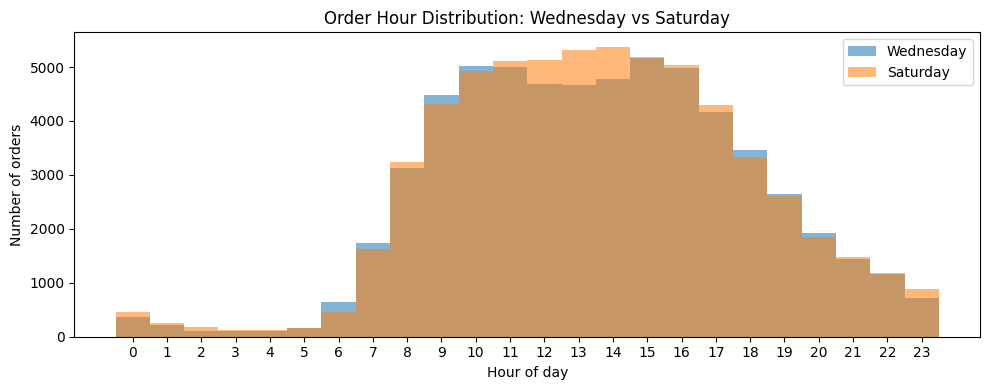

In [9]:
wed = orders.loc[orders.order_dow == 3, 'order_hour_of_day']
sat = orders.loc[orders.order_dow == 6, 'order_hour_of_day']
plt.figure(figsize=(10,4))
plt.hist(wed, bins=np.arange(25)-0.5, alpha=0.55, label='Wednesday')
plt.hist(sat, bins=np.arange(25)-0.5, alpha=0.55, label='Saturday')
plt.title('Order Hour Distribution: Wednesday vs Saturday')
plt.xlabel('Hour of day'); plt.ylabel('Number of orders'); plt.legend()
plt.xticks(range(24)); plt.tight_layout(); plt.show()

The two distributions follow a broadly similar daily rhythm, with most activity occurring from late morning through the afternoon. Differences in bar height reflect different order volumes, while the overall time-of-day pattern remains comparable.

### 3.5 Number of orders per customer

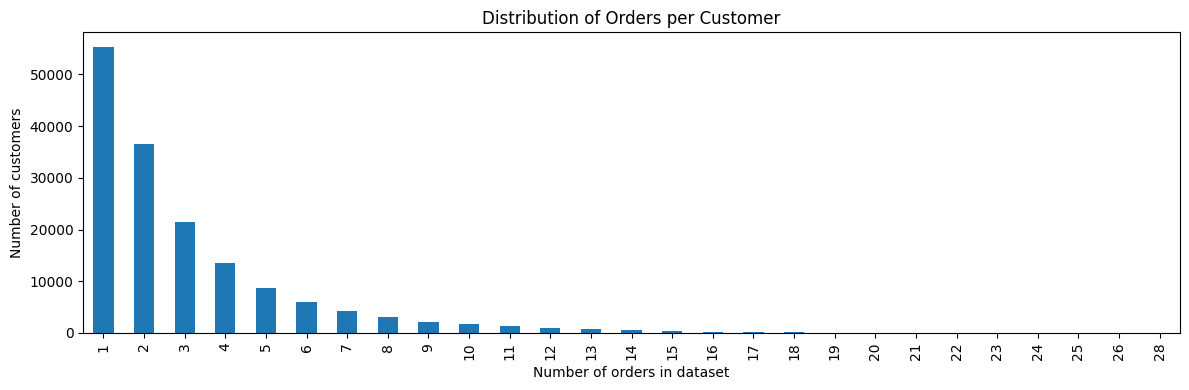

count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: order_id, dtype: float64


In [10]:
orders_per_user = orders.groupby('user_id')['order_id'].nunique()
ax = orders_per_user.value_counts().sort_index().plot(kind='bar', figsize=(12,4))
ax.set_title('Distribution of Orders per Customer')
ax.set_xlabel('Number of orders in dataset'); ax.set_ylabel('Number of customers')
plt.tight_layout(); plt.show()
print(orders_per_user.describe())

### 3.6 Top 20 most purchased products

In [11]:
top20 = (order_products.groupby('product_id').size().rename('purchase_count')
         .sort_values(ascending=False).head(20).reset_index()
         .merge(products[['product_id','product_name']], on='product_id', how='left'))
top20[['product_id','product_name','purchase_count']]

,product_id,product_name,purchase_count
0,24852,Banana,66050
1,13176,Bag of Organic Bananas,53297
2,21137,Organic Strawberries,37039
3,21903,Organic Baby Spinach,33971
4,47209,Organic Hass Avocado,29773
5,47766,Organic Avocado,24689
6,47626,Large Lemon,21495
7,16797,Strawberries,20018
8,26209,Limes,19690
9,27845,Organic Whole Milk,19600


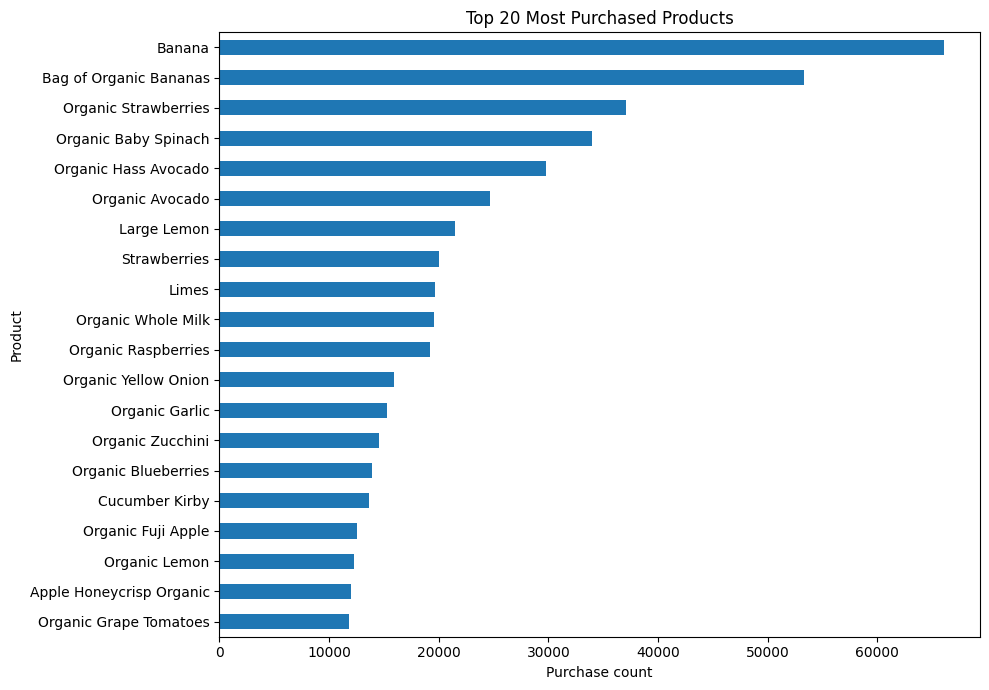

In [12]:
plot_top = top20.sort_values('purchase_count')
ax = plot_top.plot.barh(x='product_name', y='purchase_count', legend=False, figsize=(10,7))
ax.set_title('Top 20 Most Purchased Products')
ax.set_xlabel('Purchase count'); ax.set_ylabel('Product')
plt.tight_layout(); plt.show()

The ranking is dominated by frequently consumed grocery staples, particularly fresh produce. This indicates that repeat everyday items account for a large share of high-volume product activity.

### 3.7 Basket size distribution

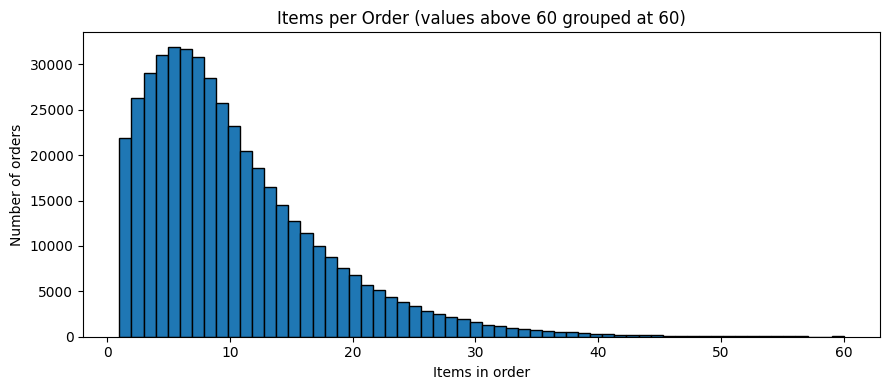

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
90%          20.000000
95%          25.000000
99%          35.000000
max         127.000000
dtype: float64


In [13]:
basket = order_products.groupby('order_id').size()
ax = basket.clip(upper=60).plot(kind='hist', bins=60, figsize=(9,4), edgecolor='black')
ax.set_title('Items per Order (values above 60 grouped at 60)')
ax.set_xlabel('Items in order'); ax.set_ylabel('Number of orders')
plt.tight_layout(); plt.show()
print(basket.describe(percentiles=[.25,.5,.75,.9,.95,.99]))

Basket size is right-skewed: most orders contain a relatively modest number of items, while a smaller group of large baskets creates a long tail.

### 3.8 Top 20 most frequently reordered products

In [14]:
reordered_top20 = (order_products.loc[order_products.reordered.eq(1)]
                   .groupby('product_id').size().rename('reorder_count')
                   .sort_values(ascending=False).head(20).reset_index()
                   .merge(products[['product_id','product_name']], on='product_id', how='left'))
reordered_top20[['product_id','product_name','reorder_count']]

,product_id,product_name,reorder_count
0,24852,Banana,55763
1,13176,Bag of Organic Bananas,44450
2,21137,Organic Strawberries,28639
3,21903,Organic Baby Spinach,26233
4,47209,Organic Hass Avocado,23629
5,47766,Organic Avocado,18743
6,27845,Organic Whole Milk,16251
7,47626,Large Lemon,15044
8,27966,Organic Raspberries,14748
9,16797,Strawberries,13945


### 3.9 Reorder proportion by product

In [15]:
product_reorder = (order_products.groupby('product_id')['reordered'].agg(['mean','count'])
                   .rename(columns={'mean':'reorder_rate','count':'purchases'}).reset_index()
                   .merge(products[['product_id','product_name']], on='product_id', how='left'))
product_reorder.sort_values(['purchases','reorder_rate'], ascending=False).head(20)[['product_id','product_name','purchases','reorder_rate']]

,product_id,product_name,purchases,reorder_rate
22808,24852,Banana,66050,0.844254
12025,13176,Bag of Organic Bananas,53297,0.834006
19370,21137,Organic Strawberries,37039,0.773212
20077,21903,Organic Baby Spinach,33971,0.772217
43271,47209,Organic Hass Avocado,29773,0.793639
43788,47766,Organic Avocado,24689,0.759164
43663,47626,Large Lemon,21495,0.699884
15364,16797,Strawberries,20018,0.696623
24047,26209,Limes,19690,0.676841
25556,27845,Organic Whole Milk,19600,0.829133


A raw reorder rate can be unstable for products with very few purchases. The table therefore includes purchase volume alongside the rate so that the metric can be interpreted in context.

### 3.10 Reorder proportion by customer
For this portfolio version, customer reorder behavior is calculated directly from the `reordered` flag in the order-item table after linking each order to its customer. This measures the share of purchased items that had been bought previously by that customer.

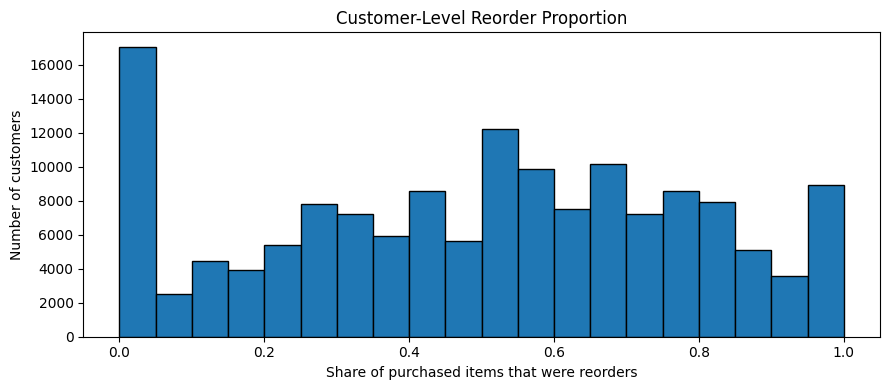

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reordered, dtype: float64


In [16]:
customer_items = order_products[['order_id','reordered']].merge(
    orders[['order_id','user_id']], on='order_id', how='inner'
)
customer_reorder = customer_items.groupby('user_id')['reordered'].mean()
ax = customer_reorder.plot(kind='hist', bins=20, figsize=(9,4), edgecolor='black')
ax.set_title('Customer-Level Reorder Proportion')
ax.set_xlabel('Share of purchased items that were reorders'); ax.set_ylabel('Number of customers')
plt.tight_layout(); plt.show()
print(customer_reorder.describe())

### 3.11 Top 20 products added first to the cart

In [17]:
first20 = (order_products.loc[order_products.add_to_cart_order.eq(1)]
           .groupby('product_id').size().rename('first_add_count')
           .sort_values(ascending=False).head(20).reset_index()
           .merge(products[['product_id','product_name']], on='product_id', how='left'))
first20[['product_id','product_name','first_add_count']]

,product_id,product_name,first_add_count
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


## 4. Key findings

The analysis highlights several behavioral patterns in the available Instacart sample:

- Ordering is strongly concentrated in **daytime hours**, with a clear peak period.
- Customer activity varies across the **days of the week**, indicating recurring shopping rhythms.
- The interval between purchases is not uniform; customers exhibit both short repeat cycles and a pronounced concentration at the 30-day boundary.
- Purchase frequency per customer is right-skewed: many customers appear only a few times in the sample, while a smaller group orders much more frequently.
- The most purchased and most reordered products are dominated by **everyday grocery staples**, especially produce.
- Basket size is also right-skewed, with most orders containing a moderate number of items and a smaller number of very large baskets.
- Reorder behavior differs across products and customers, providing a useful basis for retention, recommendation, and replenishment use cases.

## 5. Business implications

From a product and CRM perspective, these patterns could support demand-aware communication, replenishment reminders, personalized recommendations, and segmentation based on purchase cadence or reorder propensity. However, the analysis is descriptive and should not be interpreted as causal evidence.

## 6. Limitations

This project uses an adapted subset of a public dataset. The analysis describes behavior **within the available sample** and does not establish statistical causality or represent all Instacart customers. Some fields contain missing values by design, and the 30-day interval boundary may compress longer waiting periods.

## 7. Skills demonstrated

`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Data Cleaning` · `Data Wrangling` · `Exploratory Data Analysis` · `Customer Behavior` · `Product Analytics`